# Exploratory Data Analysis (EDA)

## Description of Variables

### URL Features
*   **TLD**: The Top Level Domain (e.g., .com or .edu), which is the last part of the domain name.
*   **URLLength**: The total length of the URL, which is often longer in phishing attacks due to added subdirectories or parameters.
*   **IsDomainIP**: A binary feature indicating if the URL uses an IP address instead of a domain name.
*   **NoOfSubDomain**: The count of subdomains appearing before the domain name, often used to mimic legitimate sites.
*   **NoOfObfuscatedChar**: The count of obfuscated characters (e.g., using hex encoding like `%6d`) in the URL.
*   **IsHTTPS**: A feature indicating if the webpage uses the secured HTTPS protocol or unsecured HTTP.
*   **NoOfDigits**: The count of digits present in the URL.
*   **NoOfEquals**: The count of equal signs (`=`) in the URL.
*   **NoOfQMark**: The count of question marks (`?`) in the URL.
*   **NoOfAmp**: The count of ampersand or percent symbols in the URL.

### HTML Features
*   **LargestLineLength**: The length of the longest line of code in the HTML, used to detect code obfuscation.
*   **HasTitle**: A boolean indicating if the webpage contains a title tag.
*   **HasFavicon**: A boolean indicating if the website logo is included in the favicon tag.
*   **IsResponsive**: A feature indicating if the webpage is responsive and adapts across different devices.
*   **NoOfURLRedirect**: The count of redirects found in the HTML code (e.g., using `window.location` or `refresh` tags).
*   **HasDescription**: A boolean indicating if the webpage provides a description using the `description` meta name.
*   **NoOfPopup**: The count of pop-up windows (e.g., `window.open`) used on the page.
*   **NoOfiFrame**: The count of `iframe` tags, which are often used to capture sensitive information.
*   **HasExternalFormSubmit**: A feature indicating if an HTML form submits data to an external URL.
*   **HasCopyrightInfo**: A feature indicating the presence of copyright information on the webpage.
*   **HasSocialNet**: A feature indicating the presence of social networking links or information.
*   **HasPasswordField**: A boolean indicating the presence of password entry fields in the HTML.
*   **HasSubmitButton**: A boolean indicating the presence of a submit button tag.
*   **HasHiddenFields**: A feature indicating the use of hidden fields to capture information without user knowledge.
*   **Bank, Pay, Crypto**: Features indicating the presence of terms related to financial transactions or cryptocurrency, suggesting a request for sensitive financial info.
*   **NoOfImage**: The count of images used on the webpage.
*   **NoOfJS**: The count of JavaScript blocks embedded in the HTML.
*   **NoOfSelfRef**: The count of hyperlinks that navigate to the same webpage.
*   **NoOfSelfRedirect**: The number of times a webpage automatically reloads or redirects to the same URL.
*   **NoOfEmptyRef**: The count of hyperlinks that navigate to empty links.
*   **NoOfExternalRef**: The count of hyperlinks that navigate to external webpages.

### Derived Features
*   **CharContinuationRate**: A ratio calculated by summing the longest sequences of alphabets, digits, and special characters, divided by the total URL length.
*   **URLTitleMatchScore**: A score (0 to 100) indicating the discrepancy between the URL and the webpage title; a lower score may indicate phishing.
*   **URLCharProb**: A probability calculation based on the frequency of specific characters and digits in the URL compared to patterns in legitimate and phishing datasets.
*   **TLDLegitimateProb**: A probability ratio indicating how commonly the URL's TLD is associated with legitimate websites.

### Target Variable
*   **label**: The classification target where `1` represents a legitimate URL and `0` represents a phishing URL.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Phishing_URL_ds_5percent_missing.csv").drop(columns=["FILENAME"])
with pd.option_context("display.max_columns", None):
    display(data.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31.0,NaN,24.0,0.0,com,100.0,1.000000,0.522907,0.061933,3.0,1.0,0.0,0.0,0.0,18.0,0.581,0.0,0.0,0.0,0.0,0.0,1.0,0.032,NaN,558.0,9381.0,1.0,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,34.0,20.0,NaN,119.0,0.0,124.0,1.0
1,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,NaN,100.0,0.666667,0.032650,0.050207,2.0,1.0,0.0,0.0,0.0,9.0,0.391,0.0,0.0,0.0,0.0,0.0,2.0,0.087,1.0,618.0,9381.0,1.0,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,https://www.voicefmradio.co.uk,NaN,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,0.064129,2.0,2.0,0.0,NaN,0.0,15.0,0.517,0.0,0.0,0.0,0.0,0.0,2.0,0.069,1.0,467.0,682.0,1.0,voice fm southampton,46.666667,46.666667,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,NaN,3.0,1.0,NaN,0.0,0.0,13.0,0.500,0.0,0.0,0.0,0.0,NaN,1.0,0.038,NaN,6356.0,26824.0,1.0,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,1.0,12.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,0.059441,3.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.030,1.0,6089.0,28404.0,1.0,fundaciÃ³n rewilding argentina,100.000000,100.000000,0.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0,1.0,1.0,NaN,0.0,1.0,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


In [3]:
count_columns = data.columns[data.columns.str.startswith("NoOf")]
binary_columns = data.columns[data.columns.str.startswith("Has") | data.columns.str.startswith("Is")]

In [4]:
np.setdiff1d([col for col in data.columns if data[col].nunique() == 2], binary_columns)

array(['Bank', 'Crypto', 'NoOfSelfRedirect', 'NoOfURLRedirect', 'Pay',
       'Robots', 'label'], dtype='<U21')

In [5]:
binary_columns = binary_columns.union(["Bank", "Crypto", "Pay", "Robots"])

**Note:** We may want to remove `NoOfSelfRedirect`, `NoOfURLRedirect`.

In [6]:
other_columns = np.setdiff1d(
    [
        col
        for col in data.columns
        if data[col].nunique() != 2 and data.dtypes[col] != "object"
    ],
    count_columns.union(binary_columns),
)
other_columns

array(['CharContinuationRate', 'DegitRatioInURL', 'DomainLength',
       'DomainTitleMatchScore', 'LargestLineLength', 'LetterRatioInURL',
       'LineOfCode', 'ObfuscationRatio', 'SpacialCharRatioInURL',
       'TLDLegitimateProb', 'TLDLength', 'URLCharProb', 'URLLength',
       'URLSimilarityIndex', 'URLTitleMatchScore'], dtype='<U26')

In [7]:
count_columns = count_columns.union(
    [
        "DomainLength",
        "LargestLineLength",
        "LineOfCode",
        "TLDLength",
        "URLLength",
    ]
)
score_columns = np.setdiff1d(other_columns, count_columns)

In [8]:
# Int data types are integers that allow for null.
data[binary_columns] = data[binary_columns].astype("Int8")
data[count_columns] = data[count_columns].astype("Int64")

In [9]:
(
    data.groupby("label")[count_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count          mean            std  \
                           label                                          
DomainLength               0.0     91040.0     24.462983      12.185198   
                           1.0    121689.0     19.228616       4.817042   
LargestLineLength          0.0     91163.0  20037.633711  232381.187186   
                           1.0    121610.0   7382.940145   12836.162395   
LineOfCode                 0.0     91069.0     65.888612     200.688475   
                           1.0    121641.0    1954.24135    4483.546836   
NoOfAmpersandInURL         0.0     91005.0      0.058337       1.275504   
                           1.0    121750.0           0.0            0.0   
NoOfCSS                    0.0     90910.0      0.439754       1.456386   
                           1.0    121720.0      10.76837     103.689426   
NoOfDegitsInURL            0.0     91114.0      4.297715      17.258776   
                           1.0    121809.0      0.050612       0.350135   
NoOfEmptyRef               0.0     91019.0      0.150815        1.78204   
                           1.0    121703.0      4.047649      23.659399   
NoOfEqualsInURL            0.0     91140.0      0.145348       1.359971   
                           1.0    121737.0           0.0            0.0   
NoOfExternalRef            0.0     91054.0      1.128572       3.232333   
                           1.0    121633.0     85.305575     207.573953   
NoOfImage                  0.0     91017.0      0.869057       3.313608   
                           1.0    121652.0     45.105933     102.504488   
NoOfJS                     0.0     91086.0      0.892519       3.380478   
                           1.0    121739.0     17.726152      28.021673   
NoOfLettersInURL           0.0     91043.0     28.087925      43.016295   
                           1.0    121808.0     12.935095       4.782483   
NoOfObfuscatedChar         0.0     91099.0      0.056806       2.850631   
                           1.0    121793.0           0.0            0.0   
NoOfOtherSpecialCharsInURL 0.0     91037.0      3.793798       4.627743   
                           1.0    121838.0       1.24407       0.503206   
NoOfPopup                  0.0     91030.0      0.009722       0.171789   
                           1.0    121634.0      0.381193       5.044929   
NoOfQMarkInURL             0.0     91163.0      0.069063       0.292006   
                           1.0    121657.0           0.0            0.0   
NoOfSelfRedirect           0.0     90986.0       0.05747        0.23274   
                           1.0    121836.0      0.027184        0.16262   
NoOfSelfRef                0.0     91038.0      0.490323       3.123446   
                           1.0    121734.0    113.803243       229.0116   
NoOfSubDomain              0.0     91037.0      1.168975       0.790251   
                           1.0    121803.0      1.162196       0.405011   
NoOfURLRedirect            0.0     91098.0      0.151573       0.358609   
                           1.0    121786.0      0.119743       0.324662   
NoOfiFrame                 0.0     91097.0      0.083845       0.516518   
                           1.0    121702.0      2.720399       7.567553   
TLDLength                  0.0     91012.0      2.818848       0.690366   
                           1.0    121626.0      2.723768       0.517456   
URLLength                  0.0     90991.0      45.70019      60.998609   
                           1.0    121783.0     26.228135       4.812127   

                                    min    25%     50%     75%         max  
                           label                                            
DomainLength               0.0      4.0   16.0    22.0    29.0       110.0  
                           1.0      8.0   16.0    19.0    22.0        50.0  
LargestLineLength          0.0     22.0   59.0   137.0   869.0  13975732.0  
                           1.0     84.0  874.0  306

1. **URL Structure**:
   * Legit websites do not use special characters such as `=`, `&`, and other obfuscation characters in their URLs. While phishing websites utilize them often.
  
     A note of caution: Our sample size is quite large. Still, no legit website contain these characters in their URL. It is possible that we encounter a website with some of these characters in the URL. So, we must construct any model we wish to construct with caution as to not over rely on these features in determining legit vs. phishing.

   * Phishing websites often use digits in their URLs.

   * There don't seem to be too greate a difference between the number of subdomains of either type of website. Modern websites may use many subdomains as well.

   * The domain name of a phishing website may be slightly longer.

   * TLDs are often short. The length of the TLD may not provide much information since it is not hard to come by short TLDs.

   * Phishing websites have longer URLs.

2. **Page Complexity**:
   We see that phishing websites are often simpler than legit ones. Consider the following variables:
   - `NoOfCSS`: Phishing websites contain considerably less CSS on average and the variation in it is low, while legit websites contain more CSS and the variation is high. This suggests that websites with more CSS, which are more complex, are less likely to be phishing sites, but simpler website may also be legit.
   - `NoOfImage`: Legit websites tend to contain more images.
   - `NoOfJS`: Phishing websites do not contain much JavaScript code.
   - `LineOfCode`: Legit websites contain more lines of code. This contributes to the page complexity.
   
   We see that more complex websites containing more content are more likely to be legit.

3. **Connectivity**:
   - `NoOfExternalRef`: Legit websites often link to other websites. This is expected for an established website which has had time to develop. While phishing websites, which or often created in a short period of time and are not fleshed out, do not contain many external references in general.
   - `NoOfSelfRef`: Legit websites contain more references to itself. This is indicative of complexity of the website. Websites often include links to itself for pages such as _About Us_ or _Contact Us_. Phishing websites may not include such pages.

   We see that legit websites are more connected.
   
4. **Behavioural Issues**:
   - `NoOfSelfRedirect`: Webpages do not often forcefully reload. Such behaviour may be indicative of phishing. Though, neither type of website seems to do this behaviour often. So, we may remove this variable if need be.
   - `NoOfURLRedirect`: This also seems rare and may not contribute much information. We may want to remove it.
   - `NoOfPopup`: It is highly skewed, but we see that legit websites contain more popups. This may be due to complexity of legit websites.
   - `NoOfiFrame`: There are attacks based on iFrame. Using iFrames may be indicative of phishing.

5. **Other**:
   - `LargestLineLength`:  Phishing websites may try to obfuscate their code by using extremely long lines.

In [10]:
from scipy.stats import wasserstein_distance

features = [
    "NoOfAmpersandInURL",
    "NoOfEqualsInURL",
    "NoOfObfuscatedChar",
    "NoOfQMarkInURL",
]

D = pd.DataFrame(
    index=features,
    columns=features,
    dtype=float
)

for i in features:
    for j in features:
        x1 = data[i].dropna()
        x2 = data[j].dropna()

        D.loc[i, j] = wasserstein_distance(x1, x2)

D

,NoOfAmpersandInURL,NoOfEqualsInURL,NoOfObfuscatedChar,NoOfQMarkInURL
NoOfAmpersandInURL,0.000000,0.044684,0.013406,0.040287
NoOfEqualsInURL,0.044684,0.000000,0.053650,0.038688
NoOfObfuscatedChar,0.013406,0.053650,0.000000,0.044552
NoOfQMarkInURL,0.040287,0.038688,0.044552,0.000000


Wasserstein distance is low between these features. So, they are close. But, this could be due to the fact that the masses of the distributions are concentrated at zero.

In [11]:
from sklearn.decomposition import PCA

Z = data[features].dropna()

pca = PCA(n_components=1)
pca.fit(Z)
pca.explained_variance_ratio_, pca.components_

(array([0.89102475]),
 array([[0.33067132, 0.34318027, 0.87909794, 0.00840242]]))

We see that these features can be reduced to just one and still explain 89% of the variance.

In [12]:
(
    data.groupby("label")[binary_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count      mean       std  min  25%  50%  75%  \
                      label                                                     
Bank                  0.0     91030.0  0.054015  0.226049  0.0  0.0  0.0  0.0   
                      1.0    121693.0  0.181268  0.385241  0.0  0.0  0.0  0.0   
Crypto                0.0     91084.0   0.00594   0.07684  0.0  0.0  0.0  0.0   
                      1.0    121884.0  0.036346   0.18715  0.0  0.0  0.0  0.0   
HasCopyrightInfo      0.0     91064.0  0.057531  0.232856  0.0  0.0  0.0  0.0   
                      1.0    121615.0  0.807631  0.394163  0.0  1.0  1.0  1.0   
HasDescription        0.0     91066.0  0.043814  0.204683  0.0  0.0  0.0  0.0   
                      1.0    121747.0   0.73601  0.440796  0.0  0.0  1.0  1.0   
HasExternalFormSubmit 0.0     91147.0  0.004213  0.064771  0.0  0.0  0.0  0.0   
                      1.0    121691.0   0.07312  0.260334  0.0  0.0  0.0  0.0   
HasFavicon            0.0     91026.0   0.08747  0.282523  0.0  0.0  0.0  0.0   
                      1.0    121728.0  0.566788  0.495521  0.0  0.0  1.0  1.0   
HasHiddenFields       0.0     91053.0  0.093242  0.290773  0.0  0.0  0.0  0.0   
                      1.0    121683.0   0.59074  0.491699  0.0  0.0  1.0  1.0   
HasObfuscation        0.0     91111.0  0.004741  0.068695  0.0  0.0  0.0  0.0   
                      1.0    121751.0       0.0       0.0  0.0  0.0  0.0  0.0   
HasPasswordField      0.0     90967.0  0.053855  0.225732  0.0  0.0  0.0  0.0   
                      1.0    121663.0  0.138538  0.345466  0.0  0.0  0.0  0.0   
HasSocialNet          0.0     91053.0  0.005041  0.070821  0.0  0.0  0.0  0.0   
                      1.0    121702.0  0.794358  0.404171  0.0  1.0  1.0  1.0   
HasSubmitButton       0.0     90997.0  0.085146    0.2791  0.0  0.0  0.0  0.0   
                      1.0    121842.0  0.661045  0.473357  0.0  0.0  1.0  1.0   
HasTitle              0.0     91134.0  0.677431  0.467462  0.0  0.0  1.0  1.0   
                      1.0    121710.0  0.998776  0.034968  0.0  1.0  1.0  1.0   
IsDomainIP            0.0     90989.0  0.006484  0.080264  0.0  0.0  0.0  0.0   
                      1.0    121625.0       0.0       0.0  0.0  0.0  0.0  0.0   
IsHTTPS               0.0     91048.0  0.492444  0.499946  0.0  0.0  0.0  1.0   
                      1.0    121897.0       1.0       0.0  1.0  1.0  1.0  1.0   
IsResponsive          0.0     91067.0  0.316514  0.465119  0.0  0.0  0.0  1.0   
                      1.0    121766.0    0.8545  0.352606  0.0  1.0  1.0  1.0   
Pay                   0.0     91118.0  0.059758  0.237039  0.0  0.0  0.0  0.0   
                      1.0    121776.0  0.369293  0.482615  0.0  0.0  0.0  1.0   
Robots                0.0     91078.0    0.0659  0.248108  0.0  0.0  0.0  0.0   
                      1.0    121780.0  0.416587  0.492995  0.0  0.0  0.0  1.0   

                             max  
                      label       
Bank                  0.0    1.0  
                      1.0    1.0  
Crypto                0.0    1.0  
                      1.0    1.0  
HasCopyrightInfo      0.0    1.0  
                      1.0    1.0  
HasDescription        0.0    1.0  
                      1.0    1.0  
HasExternalFormSubmit 0.0    1.0  
                      1.0    1.0  
HasFavicon            0.0    1.0  
                      1.0    1.0  
HasHiddenFields       0.0    1.0  
                      1.0    1.0  
HasObfuscation        0.0    1.0  
                      1.0    0.0  
HasPasswordField      0.0    1.0  
                      1.0    1.0  
HasSocialNet          0.0    1.0  
                      1.0    1.0  
HasSubmitButton       0.0    1.0  
                      1.0    1.0  
HasTitle              0.0    1.0  
                      1.0    1.0  
IsDomainIP            0.0    1.0  
                      1.0    0.0  
IsHTTPS               0.0    1.0  
                      1.0    1.0  
IsResponsive          0.0    1.0  
                      1.0    1

In [13]:
data[binary_columns].describe().T.sort_values(by="std")

,count,mean,std,min,25%,50%,75%,max
HasObfuscation,224050.0,0.00204,0.045117,0.0,0.0,0.0,0.0,1.0
IsDomainIP,223820.0,0.002752,0.052389,0.0,0.0,0.0,0.0,1.0
Crypto,224188.0,0.023378,0.1511,0.0,0.0,0.0,0.0,1.0
HasExternalFormSubmit,224013.0,0.043886,0.204842,0.0,0.0,0.0,0.0,1.0
HasPasswordField,223819.0,0.102355,0.303115,0.0,0.0,0.0,0.0,1.0
Bank,223884.0,0.126941,0.332907,0.0,0.0,0.0,0.0,1.0
HasTitle,223986.0,0.861148,0.345793,0.0,1.0,1.0,1.0,1.0
IsHTTPS,224126.0,0.782832,0.412319,0.0,1.0,1.0,1.0,1.0
Pay,224086.0,0.236855,0.425154,0.0,0.0,0.0,0.0,1.0
Robots,224045.0,0.26687,0.442325,0.0,0.0,0.0,1.0,1.0


These features can be broken into three categories.

1. **Trust & Identity**
   * `HasFavicon`: 
   * `HasCopyrightInfo`: Legit websites often consider legal things such as copyright, while phishing sites may not need to have any copyright information. It also seems like a good indicator.
   * `HasSocialNet`: 
   * `HasDescription`: 
   * `HasTitle`: 
2. **Form Mechanisms**
   * `HasSubmitButton`:
   * `HasPasswordField`:
   * `HasHiddenFields`:
   * `HasExternalFormSubmit `:
3. **Technical Configuration**
   * `IsHTTPS`:
   * `IsResponsive`: 
   * `IsDomainIP`, `HasObfuscation`: These features have very low variances and are also rare across both labels. They never even occur in legitimate websites. They may be a good indicator of phishing if we see either one, but it may not be worth to keep them. On a side note, even though not present in our dataset, modern legit websites do also use code obfuscation. So, this dataset may not represent the reality well.

**Mutual Information**

Calculate the mutual information between the label and the binary features.

In [14]:
from sklearn.metrics import normalized_mutual_info_score

scores = {}

for col in binary_columns:
    df = data[["label", col]].dropna()
    score = normalized_mutual_info_score(df["label"], df[col])
    scores[col] = score

mi_scores = pd.Series(scores, name="NMI")
mi_scores.sort_values(ascending=False)

HasSocialNet             0.561387
HasCopyrightInfo         0.463141
HasDescription           0.407289
IsHTTPS                  0.376182
HasSubmitButton          0.275519
HasTitle                 0.236150
IsResponsive             0.234264
HasHiddenFields          0.212978
HasFavicon               0.203445
Robots                   0.138274
Pay                      0.120010
HasExternalFormSubmit    0.041748
Bank                     0.036833
HasPasswordField         0.020179
Crypto                   0.014748
IsDomainIP               0.006726
HasObfuscation           0.004947
Name: NMI, dtype: float64

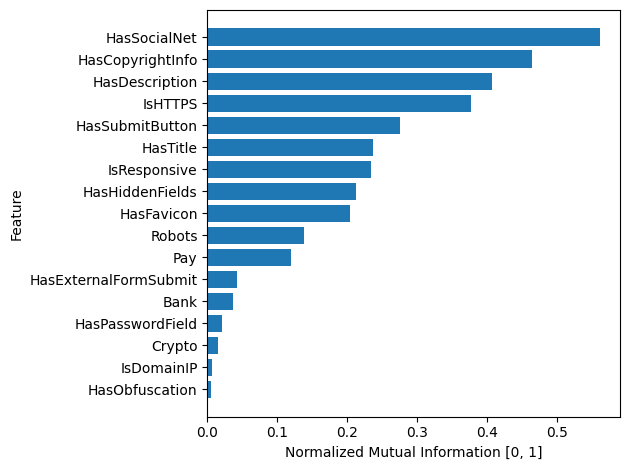

In [15]:
x = mi_scores.sort_values()
plt.barh(x.index, x.values)
plt.xlabel("Normalized Mutual Information [0, 1]")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The following binary features carry the most amount of information:
- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `IsHTTPS`

**Confusion Matrix**

Calculate the confusion matrix values between the label and the binary features.

In [17]:
from sklearn.metrics import confusion_matrix

scores = {}

for col in binary_columns:
    df = data[["label", col]].dropna()
    tn, fp, fn, tp = confusion_matrix(df["label"], df[col], labels=[0, 1]).ravel()
    scores[col] = {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TPR": tp / (tp + fn) if (tp + fn) > 0 else 0.0,  # recall
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "J": (tp * tn - fp * fn) / ((tp + fn) * (tn + fp)),  # Youden's J statistic
    }

confusion_scores = pd.DataFrame.from_dict(scores, orient="index")
confusion_scores.sort_values("J", ascending=False)

,TP,FP,TN,FN,TPR,FPR,Precision,Specificity,J
HasSocialNet,96675,459,90594,25027,0.794358,0.005041,0.995275,0.994959,0.789317
HasCopyrightInfo,98220,5239,85825,23395,0.807631,0.057531,0.949362,0.942469,0.750100
HasDescription,89607,3990,87076,32140,0.736010,0.043814,0.957370,0.956186,0.692196
HasSubmitButton,80543,7748,83249,41299,0.661045,0.085146,0.912245,0.914854,0.575899
IsResponsive,104049,28824,62243,17717,0.854500,0.316514,0.783071,0.683486,0.537985
IsHTTPS,121897,44836,46212,0,1.000000,0.492444,0.731091,0.507556,0.507556
HasHiddenFields,71883,8490,82563,49800,0.590740,0.093242,0.894368,0.906758,0.497497
HasFavicon,68994,7962,83064,52734,0.566788,0.087470,0.896538,0.912530,0.479319
Robots,50732,6002,85076,71048,0.416587,0.065900,0.894208,0.934100,0.350688
HasTitle,121561,61737,29397,149,0.998776,0.677431,0.663188,0.322569,0.321345


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from joblib import Parallel, delayed

XX = data[[*binary_columns, "label"]].dropna()

X = XX.drop(columns="label")
y = XX["label"]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=0,
    n_jobs=1,
)

baseline = cross_val_score(model, X, y, cv=5, scoring="roc_auc", n_jobs=-1).mean()

drop_importance = {}

def drop_column_score(col):
    X_drop = X.drop(columns=col)
    score = cross_val_score(model, X_drop, y, cv=5, scoring="roc_auc", n_jobs=-1).mean()
    return col, baseline - score

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(drop_column_score)(col) for col in X.columns
)

drop_importance = pd.Series(dict(results)).sort_values(ascending=False)
drop_importance

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   43.7s
[Parallel(n_jobs=-1)]: Done   2 out of  17 | elapsed:   43.9s remaining:  5.5min
[Parallel(n_jobs=-1)]: Done   4 out of  17 | elapsed:   45.3s remaining:  2.5min
[Parallel(n_jobs=-1)]: Done   6 out of  17 | elapsed:   45.6s remaining:  1.4min
[Parallel(n_jobs=-1)]: Done   8 out of  17 | elapsed:   45.8s remaining:   51.6s
[Parallel(n_jobs=-1)]: Done  10 out of  17 | elapsed:   46.1s remaining:   32.3s
[Parallel(n_jobs=-1)]: Done  12 out of  17 | elapsed:   46.4s remaining:   19.3s
[Parallel(n_jobs=-1)]: Done  14 out of  17 | elapsed:   46.7s remaining:   10.0s
[Parallel(n_jobs=-1)]: Done  17 out of  17 | elapsed:   46.9s finished


HasSocialNet             0.004042
IsHTTPS                  0.002013
HasCopyrightInfo         0.001901
HasDescription           0.001482
HasSubmitButton          0.000219
HasHiddenFields          0.000162
HasPasswordField         0.000153
HasTitle                 0.000147
IsResponsive             0.000067
HasObfuscation           0.000048
Robots                   0.000047
IsDomainIP               0.000041
HasFavicon               0.000026
Crypto                  -0.000017
HasExternalFormSubmit   -0.000034
Bank                    -0.000055
Pay                     -0.000144
dtype: float64

In [18]:
data[other_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CharContinuationRate,223894.0,0.845486,0.216669,0.0,0.68,1.0,1.0,1.0
DegitRatioInURL,224127.0,0.028588,0.070845,0.0,0.0,0.0,0.0,0.684
DomainLength,223911.0,21.472371,9.150128,4.0,16.0,20.0,24.0,110.0
DomainTitleMatchScore,223967.0,50.09429,49.676739,0.0,0.0,75.0,100.0,100.0
LargestLineLength,223965.0,12839.056567,154216.520977,22.0,200.0,1087.0,8047.0,13975732.0
LetterRatioInURL,223984.0,0.515956,0.123315,0.0,0.435,0.519,0.594,0.926
LineOfCode,223964.0,1143.0961,3469.014962,2.0,18.0,429.0,1277.0,442666.0
ObfuscationRatio,224025.0,0.000136,0.0038,0.0,0.0,0.0,0.0,0.348
SpacialCharRatioInURL,223992.0,0.063316,0.03238,0.0,0.038,0.05,0.083,0.397
TLDLegitimateProb,223989.0,0.260437,0.251632,0.0,0.005977,0.079963,0.522907,0.522907


## Question 1

Are phishing URLs more likely to contain digits?

In [19]:
data.groupby("label")["NoOfDegitsInURL"].mean()

label
0.0    4.297715
1.0    0.050612
Name: NoOfDegitsInURL, dtype: Float64

We see that legitimate URLs contain almost no digits, while phishing URLs contain about 4 digits on average.

Next, let's look at the distribution of the digits used by phishing URLs.

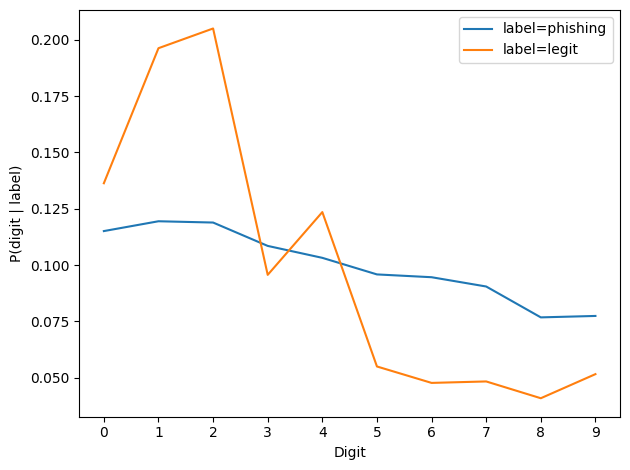

In [20]:
digits = list("0123456789")
digit_counts = (
    data.assign(digit=data["URL"].str.findall(r"\d"))
    .explode("digit")
    .groupby(["label", "digit"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=digits, fill_value=0)
)
digit_probs = digit_counts.div(digit_counts.sum(axis=1), axis=0)

plt.figure()
for label in digit_probs.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

This plot shows us the probability of the occurrence of each digit given that we know the character is a digit. We see that the digits included in the phishing URLs are distributed more uniformly. This makes sense since most of these domain names are generated randomly. However, the digit distribution of legit URLs are more centered around lower values such as 1 and 2. Next, we look at the probability of seeing a digit in the URL in general.

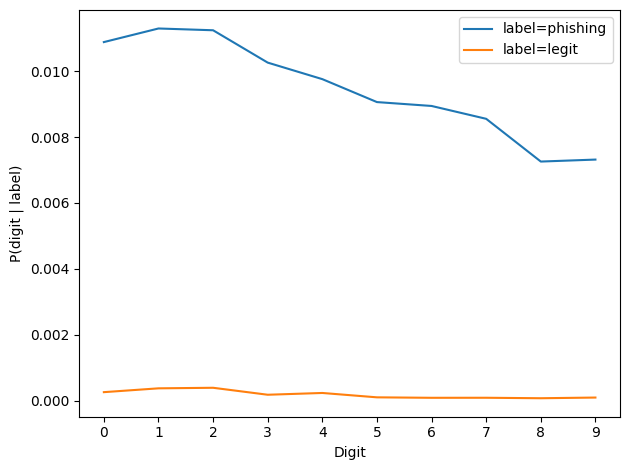

In [21]:
digit_probs_grand = digit_counts.div(data[["label", "URLLength"]].groupby("label").sum()["URLLength"], axis=0)

plt.figure()
for label in digit_probs_grand.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs_grand.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

We see that the it is not very likely to see a digit in a legit URL. However, phishing URLs include disproportionately high number of digits.